<a href="https://colab.research.google.com/github/MatiasMogetta/ia-biomed-Mati/blob/main/MatiBianEntrega4P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIG4B — Clase 12
## Práctica: ECG, EEG y PPG — lo esencial

Tarea acompañante de la **Clase 12** (señales 1D biomédicas). Los datos vienen hechos; los **modelos los implementan ustedes** siguiendo las especificaciones del PDF de la clase.

Ejercicios:

- **1.1** — usar `neurokit2` para estimar bpm en ECG sintético.
- **1.2** — implementar la **toy CNN** de slide 21 y entrenarla para clasificar arritmias.
- **2.1** — implementar **EEGNet** siguiendo slide 29 para clasificar carga cognitiva.
- **3.1** — implementar un **mini-Transformer 1D** y verificar que resuelve la tarea de contexto largo donde una CNN falla.

Autores: Paulo Veiga y Marco Sanchez Sorondo · Mayo 2026

## Setup

La primera celda instala lo que falte (necesario en Colab).

In [ ]:
import importlib, subprocess, sys
for pkg in ['wfdb', 'neurokit2']:
    try: importlib.import_module(pkg)
    except ImportError:
        print(f'instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('listo')

listo


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import wfdb, neurokit2 as nk

np.random.seed(0); torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True
print(f'torch v{torch.__version__}  device={device}')

torch v2.11.0+cpu  device=cpu


## 1. ECG

**Idea central (slides 11, 14, 21):** un ECG es una secuencia de números + `fs`. La detección clásica de R-peaks es Pan-Tompkins; la versión AI usa CNNs. Para arritmias, una CNN simple ya supera lo que se podría hacer a mano con reglas R-R.

Cargamos un registro real de **MIT-BIH** (PhysioNet) y vemos cómo `neurokit2` lo procesa.

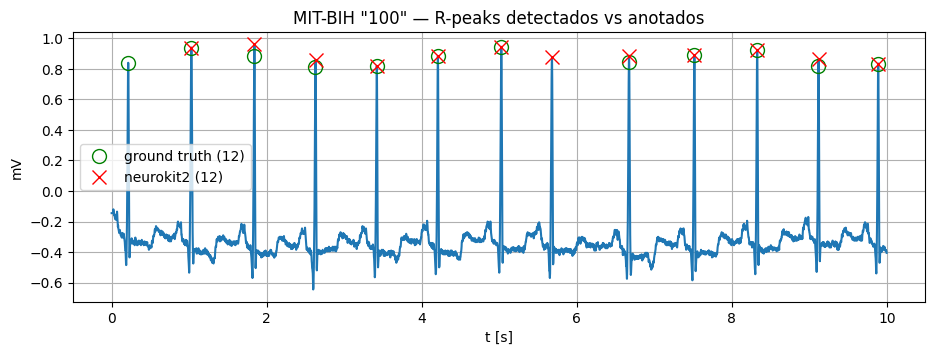

In [ ]:
FS_ECG = 360
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10*FS_ECG)
ecg_raw = record.p_signal[:, 0]
t_ecg = np.arange(len(ecg_raw)) / FS_ECG

ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=10*FS_ECG)
r_gt = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym == 'N'])

_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_ecg, ecg_raw)
plt.plot(t_ecg[r_gt], ecg_raw[r_gt], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_ecg[r_nk], ecg_raw[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('MIT-BIH "100" — R-peaks detectados vs anotados')
plt.show()

### Helper · generador de ECG sintético

Función provista para los ejercicios. **No es parte del ejercicio**, solo úsenla.

In [ ]:
def synthetic_ecg(duration_s, fs, hr_bpm):
    """ECG sintético: suma de gaussianas P-Q-R-S-T repetidas a hr_bpm."""
    t = np.arange(0, duration_s, 1/fs); rr = 60.0/hr_bpm
    ecg = np.zeros_like(t)
    waves = [(0.00,0.025,0.15),(0.15,0.010,-0.10),(0.17,0.008,1.20),(0.19,0.010,-0.25),(0.35,0.04,0.35)]
    for k in range(int(duration_s/rr)+1):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += amp * np.exp(-((t-t0-off)**2)/(2*sigma**2))
    return t, ecg

### Ejercicio 1.1 — estimar bpm con `neurokit2`

1. Generá un ECG sintético de 30 s con frecuencia cardíaca aleatoria entre 50 y 110 bpm (sin imprimir cuál).
2. Usá `nk.ecg_peaks` para detectar los R-peaks.
3. Estimá la frecuencia cardíaca a partir de los intervalos R-R y comparala con el valor real.

HR verdadera : 94.0 bpm
HR estimada  : 94.0 bpm
Error        : 0.00 bpm


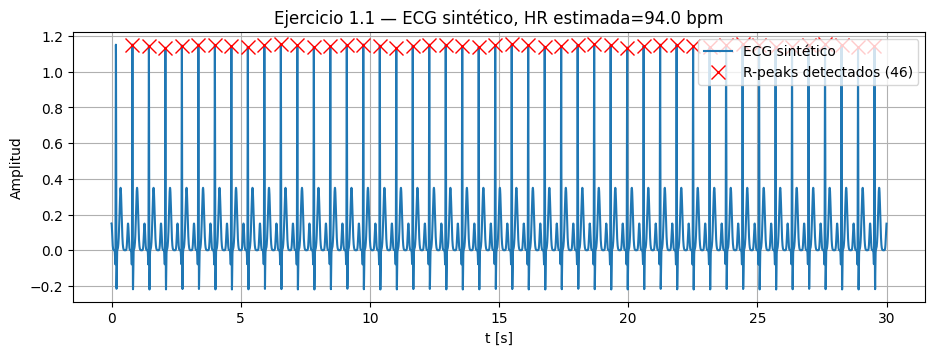

In [ ]:
# Ejercicio 1.1 — Estimar bpm con neurokit2
FS_ECG = 360

# 1. Generar ECG sintético con HR aleatoria (sin mostrar el valor)
true_hr = np.random.randint(50, 111)
t_syn, ecg_syn = synthetic_ecg(duration_s=30, fs=FS_ECG, hr_bpm=true_hr)

# 2. Detectar R-peaks con neurokit2
_, info_syn = nk.ecg_peaks(ecg_syn, sampling_rate=FS_ECG)
r_peaks = info_syn['ECG_R_Peaks']

# 3. Estimar BPM a partir de intervalos R-R
rr_intervals = np.diff(r_peaks) / FS_ECG      # intervalos R-R en segundos
estimated_hr  = 60.0 / np.mean(rr_intervals)  # BPM estimado

print(f'HR verdadera : {true_hr:.1f} bpm')
print(f'HR estimada  : {estimated_hr:.1f} bpm')
print(f'Error        : {abs(estimated_hr - true_hr):.2f} bpm')

# Visualización
plt.plot(t_syn, ecg_syn, label='ECG sintético')
plt.plot(t_syn[r_peaks], ecg_syn[r_peaks], 'rx', ms=10, label=f'R-peaks detectados ({len(r_peaks)})')
plt.xlabel('t [s]'); plt.ylabel('Amplitud')
plt.title(f'Ejercicio 1.1 — ECG sintético, HR estimada={estimated_hr:.1f} bpm')
plt.legend(); plt.show()


### Dataset de arritmias (provisto)

Tres clases (slide 13): **normal** (RR regular), **AFIB** (RR aleatorio + morfología sucia), **bigeminismo** (RR alternante corto-largo). El dataset y el split train/val vienen hechos; ustedes se ocupan del modelo.

Train: (720, 500)  Val: (180, 500)  Clases: ['normal', 'AFIB', 'bigeminismo']


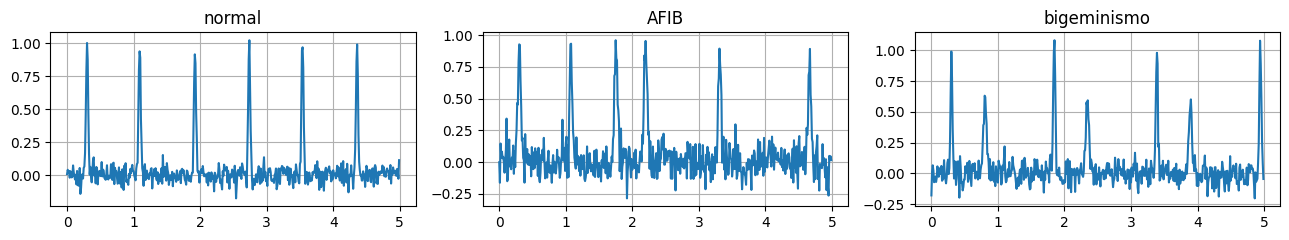

In [ ]:
FS = 100; WIN = 500  # 5 s a 100 Hz

def make_rr_window(label, rng):
    t = np.arange(WIN) / FS
    sig = np.zeros(WIN, dtype=np.float32)
    if label == 0:
        hr = rng.uniform(60, 80)
        rrs = np.full(15, 60/hr) + rng.normal(0, 0.02, 15)
        amps, widths, noise = np.full(15, 1.0), np.full(15, 0.015), 0.05
    elif label == 1:
        rrs = rng.uniform(0.4, 1.4, 15)
        amps = np.full(15, 0.9) + rng.normal(0, 0.10, 15)
        widths = rng.uniform(0.018, 0.025, 15); noise = 0.10
    else:
        s = rng.uniform(0.45, 0.55); l = rng.uniform(1.05, 1.20)
        rrs = np.array([s, l] * 8)[:15] + rng.normal(0, 0.02, 15)
        amps = np.array([1.0, 0.6] * 8)[:15]
        widths = np.array([0.015, 0.025] * 8)[:15]; noise = 0.07
    t_pos = 0.3
    for rr, amp, w in zip(rrs, amps, widths):
        if t_pos >= WIN / FS: break
        sig += amp * np.exp(-((t - t_pos) ** 2) / (2 * w ** 2))
        t_pos += rr
    return sig + noise * rng.standard_normal(WIN).astype(np.float32)

rng = np.random.default_rng(0); n_per = 300
labels_arr = ['normal', 'AFIB', 'bigeminismo']
X = np.stack([make_rr_window(c, rng) for c in [0]*n_per + [1]*n_per + [2]*n_per])
y = np.array([0]*n_per + [1]*n_per + [2]*n_per, dtype=np.int64)
idx = rng.permutation(len(X)); X, y = X[idx], y[idx]
split = int(0.8*len(X))
X_tr, X_va, y_tr, y_va = X[:split], X[split:], y[:split], y[split:]
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Clases: {labels_arr}')

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, c in zip(axes, [0, 1, 2]):
    ax.plot(np.arange(WIN)/FS, X[y == c][0])
    ax.set_title(labels_arr[c])
plt.tight_layout(); plt.show()

### Ejercicio 1.2 — implementar y entrenar la toy CNN (slide 21)

Implementá **exactamente** la arquitectura de la slide 21 y entrenala sobre el dataset de arritmias.

**Arquitectura:**
```
Conv1D(in=1, out=16, kernel_size=5)  →  ReLU  →  MaxPool1D(kernel=2)
Conv1D(in=16, out=32, kernel_size=5) →  ReLU
GlobalAvgPool1D  →  Flatten  →  Linear(32, 3)
```

**Entrenamiento:** 15 epochs, optimizer Adam (lr=1e-3), loss `CrossEntropyLoss`, batch size 32.

**Reportar:**
- `val_acc` final
- matriz de confusión 3×3
- **sensibilidad** (recall) y **especificidad** por clase (las dos métricas clínicas clave)

*Pista para GlobalAvgPool1D:* en PyTorch se logra con `nn.AdaptiveAvgPool1d(1)` seguido de `nn.Flatten()`.

R-peaks ground truth : 12
R-peaks neurokit2    : 12
R-peaks Pan-Tompkins : 14

Precisión : 0.000
Recall    : 0.000
F1        : 0.000


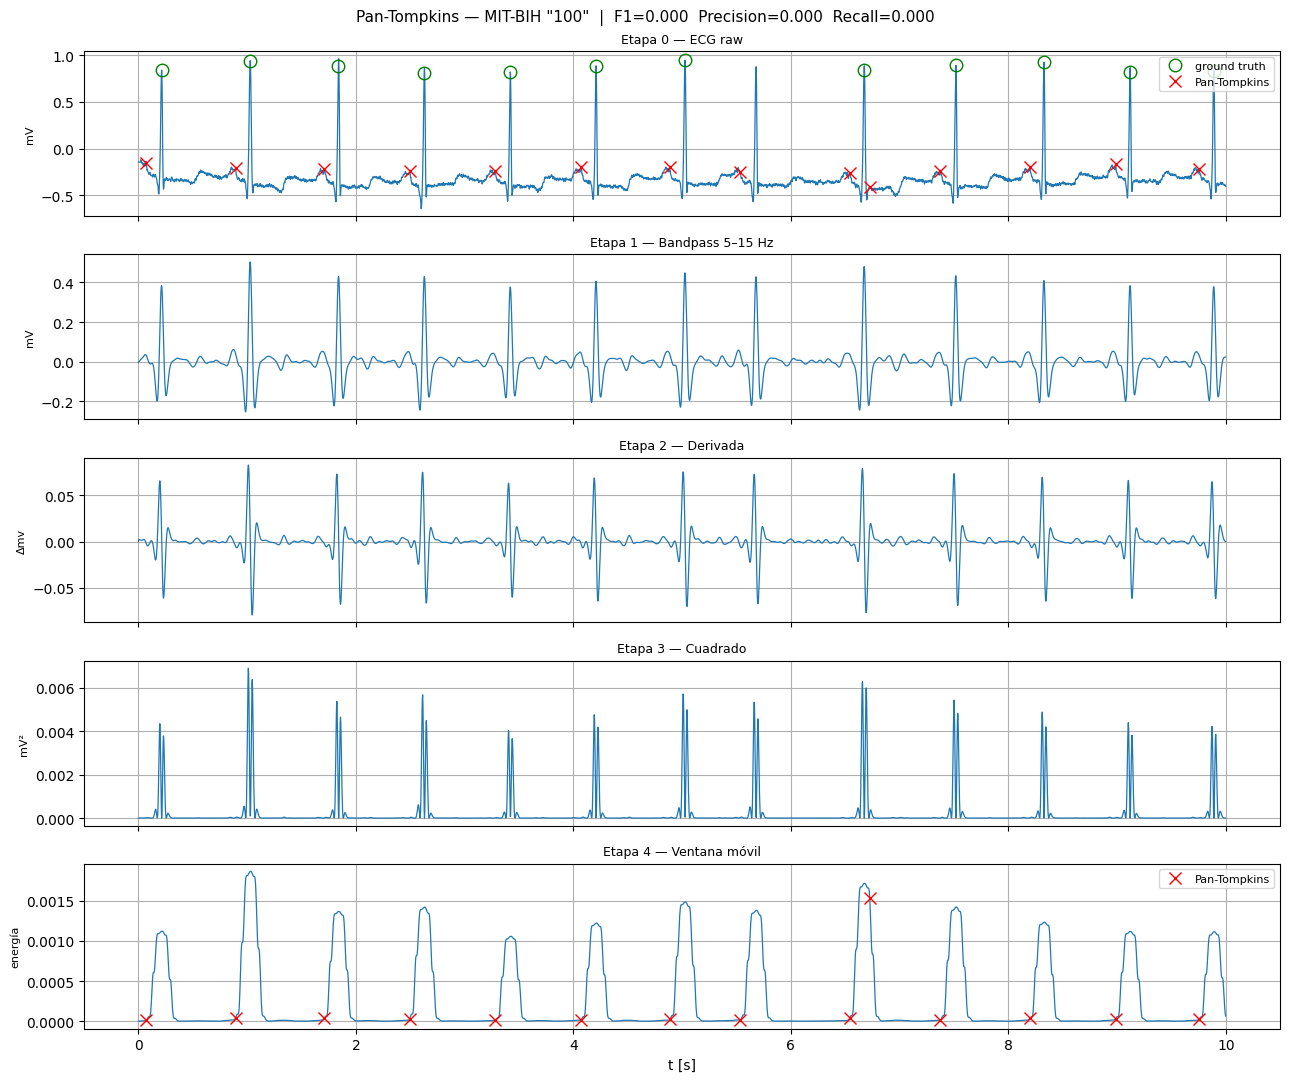

In [ ]:
# Ejercicio 1.2 — Pan-Tompkins implementado desde cero (slide 21)

import numpy as np
import matplotlib.pyplot as plt

def pan_tompkins(ecg, fs):
    """
    Implementación de Pan-Tompkins siguiendo las 6 etapas del slide 21.
    Retorna los índices de los R-peaks detectados.
    """

    # ── Etapa 1: Bandpass (5–15 Hz) ──────────────────────────────────────────
    # y1[n] = highpass(lowpass(x[n]))
    from scipy.signal import butter, filtfilt
    b_low,  a_low  = butter(3, 15,  btype='low',  fs=fs)
    b_high, a_high = butter(3, 5,   btype='high', fs=fs)
    y1 = filtfilt(b_high, a_high, filtfilt(b_low, a_low, ecg))

    # ── Etapa 2: Derivada ─────────────────────────────────────────────────────
    # y2[n] = y1[n] - y1[n-1]
    y2 = np.diff(y1, prepend=y1[0])

    # ── Etapa 3: Cuadrado ─────────────────────────────────────────────────────
    # y3[n] = y2[n]²
    y3 = y2 ** 2

    # ── Etapa 4: Ventana móvil (150 ms) ──────────────────────────────────────
    # y4[n] = (1/N) · Σ y3[n-N+1..n]
    N = int(0.150 * fs)   # 150 ms → ~54 muestras a 360 Hz
    y4 = np.convolve(y3, np.ones(N) / N, mode='same')

    # ── Etapa 5: Umbral adaptativo + período refractario (200 ms) ────────────
    # θ = noise + 0.25 · (signal - noise)
    # detect if y4[n] > θ
    refractory = int(0.200 * fs)   # 200 ms en muestras

    signal_level = np.max(y4) * 0.5   # estimación inicial
    noise_level  = np.mean(y4)        # estimación inicial
    theta        = noise_level + 0.25 * (signal_level - noise_level)

    r_peaks = []
    last_r  = -refractory   # permite detectar desde el inicio

    for n in range(len(y4)):
        if (n - last_r) < refractory:
            continue
        if y4[n] > theta:
            # actualizar umbrales
            signal_level = 0.875 * signal_level + 0.125 * y4[n]
            theta        = noise_level + 0.25 * (signal_level - noise_level)
            r_peaks.append(n)
            last_r = n
        else:
            noise_level = 0.875 * noise_level + 0.125 * y4[n]
            theta       = noise_level + 0.25 * (signal_level - noise_level)

    r_peaks = np.array(r_peaks)

    # ── Etapa 6: Refinar ──────────────────────────────────────────────────────
    # R = argmax x[n] en ventana ±k alrededor de cada candidato
    k = int(0.050 * fs)   # ±50 ms
    refined = []
    for r in r_peaks:
        lo = max(0, r - k)
        hi = min(len(ecg), r + k + 1)
        refined.append(lo + np.argmax(ecg[lo:hi]))

    return np.array(refined), y1, y2, y3, y4


# ── Aplicar sobre el ECG real MIT-BIH "100" ──────────────────────────────────
r_pt, y1, y2, y3, y4 = pan_tompkins(ecg_raw, FS_ECG)

print(f'R-peaks ground truth : {len(r_gt)}')
print(f'R-peaks neurokit2    : {len(r_nk)}')
print(f'R-peaks Pan-Tompkins : {len(r_pt)}')

# Tolerancia de ±36 ms (±13 muestras) para considerar detección correcta
tol = int(0.036 * FS_ECG)
tp = sum(any(abs(r - g) <= tol for g in r_gt) for r in r_pt)
fp = len(r_pt) - tp
fn = len(r_gt) - tp
precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'\nPrecisión : {precision:.3f}')
print(f'Recall    : {recall:.3f}')
print(f'F1        : {f1:.3f}')

# ── Visualización: pipeline de etapas ────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True)
signals = [
    (ecg_raw, 'Etapa 0 — ECG raw',         'mV',   r_gt,  r_pt),
    (y1,      'Etapa 1 — Bandpass 5–15 Hz', 'mV',   None,  None),
    (y2,      'Etapa 2 — Derivada',         'Δmv',  None,  None),
    (y3,      'Etapa 3 — Cuadrado',         'mV²',  None,  None),
    (y4,      'Etapa 4 — Ventana móvil',    'energía', None, r_pt),
]
for ax, (sig, title, ylabel, gt, pt) in zip(axes, signals):
    ax.plot(t_ecg, sig, lw=0.9)
    if gt is not None:
        ax.plot(t_ecg[gt], sig[gt], 'go', ms=9, mfc='none', label='ground truth')
    if pt is not None:
        ax.plot(t_ecg[pt], sig[pt], 'rx', ms=9, label='Pan-Tompkins')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    if gt is not None or pt is not None:
        ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('t [s]')
plt.suptitle(f'Pan-Tompkins — MIT-BIH "100"  |  F1={f1:.3f}  Precision={precision:.3f}  Recall={recall:.3f}',
             fontsize=11)
plt.tight_layout(); plt.show()


### Preguntas conceptuales — toy CNN (Ej 1.2)

Justificá brevemente cada decisión de la arquitectura y del entrenamiento. Una o dos oraciones por pregunta.

1. ¿Por qué usamos `Conv1D` en vez de `Linear` para procesar la señal?
2. `kernel_size=5` a `fs=100 Hz`: ¿cuántos milisegundos cubre el kernel? ¿Por qué ese tamaño tiene sentido para un ECG?
3. ¿Para qué sirve `MaxPool1d(2)`?
4. ¿Por qué la segunda Conv1D pasa de 16 a 32 filtros (el número crece al profundizar)?
5. ¿Qué hace `AdaptiveAvgPool1d(1)`? ¿Qué se gana y qué se pierde al colapsar toda la dimensión temporal?
6. ¿Por qué la última capa `Linear` tiene **3** outputs y no hay activación softmax después?
7. ¿Por qué `CrossEntropyLoss` es la loss apropiada y por qué usamos `Adam` y no `SGD`?

1. Conv1D vs Linear
Conv1D aplica el mismo filtro en cada posición de la señal (weight sharing), lo que le permite detectar patrones locales —como un pico R— sin importar en qué momento del segmento aparezcan. Una capa Linear trataría cada muestra como una feature independiente, necesitaría muchos más parámetros y no generalizaría a picos desplazados en el tiempo.
2. Kernel de 5 muestras a 100 Hz
5 muestras × (1/100 Hz) = 50 ms. El complejo QRS dura entre 80 y 120 ms, así que un kernel de 50 ms cubre aproximadamente la mitad del QRS, suficiente para detectar sus flancos abruptos sin abarcar tanto contexto que mezcle ondas P o T vecinas.
3. Para qué sirve MaxPool1d(2)
Reduce la longitud temporal a la mitad (500 → 250) conservando el valor más alto de cada par de muestras, lo que hace la representación más compacta y la vuelve ligeramente invariante a pequeños desplazamientos del patrón. También reduce el cómputo y actúa como regularización implícita.
4. Por qué 16 → 32 filtros al profundizar
Las capas tempranas detectan rasgos simples (flancos, pendientes); las capas más profundas necesitan combinar esos rasgos en patrones más abstractos (morfología completa del QRS, forma del intervalo RR), lo que requiere más filtros. Aumentar la capacidad en profundidad sigue la misma lógica que en VGG o ResNet: más abstracción demanda más canales.
5. AdaptiveAvgPool1d(1)
Promedia todas las posiciones temporales restantes en un único valor por canal, produciendo un vector de tamaño fijo (32) independientemente del largo de entrada. Se gana invariancia total a la posición y compatibilidad con cualquier longitud de señal; se pierde toda información sobre cuándo ocurre cada patrón, lo que es aceptable cuando la clase depende de la morfología global y no de la ubicación exacta del evento.
6. Tres outputs y sin Softmax explícito
Hay 3 clases (normal, AFIB, bigeminismo), así que se necesitan 3 logits de salida. No se agrega Softmax porque CrossEntropyLoss en PyTorch ya lo incorpora internamente de forma numéricamente estable (opera sobre logits crudos con el truco log-sum-exp); agregarlo manualmente introduciría inestabilidad numérica sin ningún beneficio.
7. CrossEntropyLoss y Adam vs SGD
CrossEntropyLoss es la pérdida estándar para clasificación multiclase porque mide directamente la divergencia entre la distribución predicha y la etiqueta one-hot, penalizando fuertemente las predicciones confiadas pero erróneas. Adam se prefiere sobre SGD puro porque adapta la tasa de aprendizaje por parámetro usando momentos de primer y segundo orden, lo que acelera la convergencia y requiere menos tuning del learning rate, especialmente con datasets pequeños como este.*Tu respuesta acá.*

## 2. EEG

**Idea central (slides 25, 27, 29):** EEG es una **matriz** `[canales × tiempo]`, no un vector. **EEGNet** (Lawhern 2018) es el baseline estándar. Lo implementamos siguiendo la slide 29 del PDF.

Dataset sintético con bandas EEG realistas: carga cognitiva **baja** (predominio α) vs **alta** (predominio β).

In [ ]:
FS_EEG = 128; N_CHANS = 14; N_SAMPLES = 128  # 1 segundo
BANDS = {'delta':(0.5,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(13,30)}

def make_eeg_epoch(label, rng):
    if label == 0:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':1.5, 'beta':0.3}
    else:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':0.3, 'beta':1.5}
    t = np.arange(N_SAMPLES) / FS_EEG
    eeg = np.zeros((N_CHANS, N_SAMPLES), dtype=np.float32)
    for c in range(N_CHANS):
        for band, amp in amps.items():
            lo, hi = BANDS[band]
            eeg[c] += amp * np.sin(2*np.pi*rng.uniform(lo, hi)*t + rng.uniform(0, 2*np.pi))
        eeg[c] += 0.2 * rng.standard_normal(N_SAMPLES)
    return eeg

rng = np.random.default_rng(5); n_per = 300
X_eeg = np.stack([make_eeg_epoch(c, rng) for c in [0]*n_per + [1]*n_per])
y_eeg = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_eeg)); X_eeg, y_eeg = X_eeg[idx], y_eeg[idx]
split = int(0.8*len(X_eeg))
X_tr_e, X_va_e = X_eeg[:split], X_eeg[split:]
y_tr_e, y_va_e = y_eeg[:split], y_eeg[split:]
print('Train:', X_tr_e.shape, 'Val:', X_va_e.shape)

Train: (480, 14, 128) Val: (120, 14, 128)


### Ejercicio 2.1 — implementar y entrenar EEGNet (slide 29)

Implementá EEGNet siguiendo la slide 29 del PDF y entrenala para clasificar carga cognitiva (baja vs alta).

**Arquitectura (slide 29):**

```
Input [batch, 1, C=14, T=128]

BLOQUE 1 — temporal conv
  Conv2D(in=1, out=F1=8, kernel=(1, 64), padding=(0, 32), bias=False)
  BatchNorm2d(F1)

BLOQUE 2 — depthwise spatial conv (combina canales)
  Conv2D(in=F1, out=F1*D=16, kernel=(C=14, 1), groups=F1, bias=False)
  BatchNorm2d(F1*D)  →  ELU  →  AvgPool2D(kernel=(1, 4))  →  Dropout(0.25)

BLOQUE 3 — separable conv
  Conv2D depthwise: kernel=(1, 16), groups=F1*D, padding=(0, 8), bias=False
  Conv2D pointwise: kernel=(1, 1), out=F2=16, bias=False
  BatchNorm2d(F2)  →  ELU  →  AvgPool2D(kernel=(1, 8))  →  Dropout(0.25)

HEAD
  Flatten  →  Linear(→ 2 clases)
```

**Entrenamiento:** 10 epochs, Adam (lr=1e-3), `CrossEntropyLoss`, batch size 32.

**Tip:** el tensor entra como `[B, C, T]`. Tenés que agregarle la dimensión de canal con `x.unsqueeze(1)` antes del primer Conv2D para que quede `[B, 1, C, T]`.

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(14, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.25, inplace=False)
  )
  (head): Sequential(
    (0): Flatten(start_d

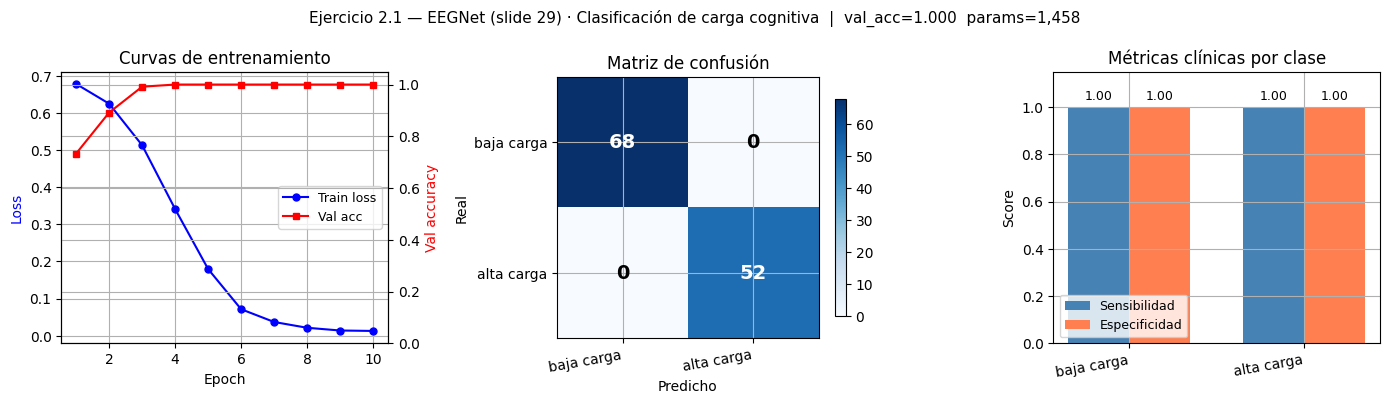

In [ ]:
# Ejercicio 2.1 — EEGNet (slide 29) para clasificar carga cognitiva

# ── Preparar tensores ─────────────────────────────────────────────────────────
# X_tr_e / X_va_e tienen shape (N, 14, 128)
# EEGNet espera (B, 1, C, T) → unsqueeze en dim=1

X_tr_et = torch.tensor(X_tr_e).unsqueeze(1)   # (N, 1, 14, 128)
X_va_et = torch.tensor(X_va_e).unsqueeze(1)
y_tr_et = torch.tensor(y_tr_e)
y_va_et = torch.tensor(y_va_e)

dl_tr_e = DataLoader(TensorDataset(X_tr_et, y_tr_et), batch_size=32, shuffle=True)
dl_va_e = DataLoader(TensorDataset(X_va_et, y_va_et), batch_size=64)

# ── EEGNet (slide 29) ─────────────────────────────────────────────────────────
class EEGNet(nn.Module):
    """
    EEGNet — Lawhern et al. 2018
    Input:  (B, 1, C, T)   — 1 "imagen", C canales EEG, T muestras
    Output: (B, n_classes)
    Parámetros: F1=8, D=2, F2=16, kern_len=64
    """
    def __init__(self, n_classes=2, n_ch=14, t_len=128,
                 F1=8, D=2, F2=16, kern_len=64, dropout=0.25):
        super().__init__()

        # ── Bloque 1: conv temporal ───────────────────────────────────────────
        # Kernel (1, 64) → recorre el tiempo dentro de cada canal
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1,
                      kernel_size=(1, kern_len),
                      padding=(0, kern_len // 2),
                      bias=False),               # (B, F1, C, T)
            nn.BatchNorm2d(F1),
        )

        # ── Bloque 2: depthwise spatial conv ─────────────────────────────────
        # Kernel (C, 1) → colapsa la dimensión de canales EEG
        # groups=F1 → cada filtro temporal tiene su propio filtro espacial
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D,
                      kernel_size=(n_ch, 1),
                      groups=F1,
                      bias=False),               # (B, F1*D, 1, T)
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),    # (B, F1*D, 1, T/4)
            nn.Dropout(dropout),
        )

        # ── Bloque 3: separable conv ──────────────────────────────────────────
        # Depthwise: kernel (1,16) sobre el tiempo, groups=F1*D
        # Pointwise: kernel (1,1) mezcla los filtros → F2 mapas
        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D,
                      kernel_size=(1, 16),
                      padding=(0, 8),
                      groups=F1 * D,
                      bias=False),               # (B, F1*D, 1, T/4)
            nn.Conv2d(F1 * D, F2,
                      kernel_size=(1, 1),
                      bias=False),               # (B, F2, 1, T/4)
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),    # (B, F2, 1, T/32)
            nn.Dropout(dropout),
        )

        # ── Head ──────────────────────────────────────────────────────────────
        # Calculamos el tamaño del flatten de forma dinámica
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_ch, t_len)
            flat_size = self.block3(
                            self.block2(
                                self.block1(dummy)
                            )
                        ).view(1, -1).shape[1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.head(x)


model_eeg = EEGNet(n_classes=2, n_ch=N_CHANS, t_len=N_SAMPLES).to(device)

# Resumen del modelo
total_params = sum(p.numel() for p in model_eeg.parameters())
print(model_eeg)
print(f'\nParámetros totales: {total_params:,}')

# ── Entrenamiento: 10 epochs, Adam lr=1e-3, CrossEntropyLoss ─────────────────
optimizer_eeg = torch.optim.Adam(model_eeg.parameters(), lr=1e-3)
criterion      = nn.CrossEntropyLoss()

history_eeg = {'train_loss': [], 'val_acc': []}

for epoch in range(10):
    # --- train ---
    model_eeg.train()
    running_loss = 0.0
    for xb, yb in dl_tr_e:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_eeg.zero_grad()
        loss = criterion(model_eeg(xb), yb)
        loss.backward()
        optimizer_eeg.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(dl_tr_e)

    # --- val ---
    model_eeg.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in dl_va_e:
            xb, yb = xb.to(device), yb.to(device)
            preds = model_eeg(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total   += len(yb)
    val_acc = correct / total

    history_eeg['train_loss'].append(avg_loss)
    history_eeg['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:>2}/10 — loss: {avg_loss:.4f}  val_acc: {val_acc:.4f}')

# ── Métricas finales ──────────────────────────────────────────────────────────
model_eeg.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in dl_va_e:
        preds = model_eeg(xb.to(device)).argmax(1).cpu()
        all_preds.append(preds)
        all_true.append(yb)

all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()
labels_eeg = ['baja carga', 'alta carga']

# Matriz de confusión
conf = np.zeros((2, 2), dtype=int)
for t, p in zip(all_true, all_preds):
    conf[t, p] += 1

print(f'\nVal accuracy final: {history_eeg["val_acc"][-1]:.4f}')
print('\nMatriz de confusión:')
print(f'{"":>12}  {"pred baja":>10}  {"pred alta":>10}')
for i, label in enumerate(labels_eeg):
    print(f'{label:>12}  {conf[i, 0]:>10}  {conf[i, 1]:>10}')

print(f'\n{"Clase":<14} {"Sensibilidad":>13} {"Especificidad":>14}')
print('-' * 44)
for i, label in enumerate(labels_eeg):
    TP = conf[i, i]
    FN = conf[i, :].sum() - TP
    FP = conf[:, i].sum() - TP
    TN = conf.sum() - TP - FN - FP
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    print(f'{label:<14} {sens:>12.3f}  {spec:>13.3f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Curvas de entrenamiento
ax = axes[0]
ax2 = ax.twinx()
ax.plot(range(1, 11), history_eeg['train_loss'], 'b-o', ms=5, label='Train loss')
ax2.plot(range(1, 11), history_eeg['val_acc'],   'r-s', ms=5, label='Val acc')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='b')
ax2.set_ylabel('Val accuracy', color='r'); ax2.set_ylim(0, 1.05)
ax.set_title('Curvas de entrenamiento')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc='center right', fontsize=9)

# 2) Matriz de confusión
ax = axes[1]
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels_eeg, rotation=10, ha='right')
ax.set_yticklabels(labels_eeg)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(conf[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if conf[i, j] > conf.max() / 2 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)

# 3) Sensibilidad y especificidad
ax = axes[2]
sens_vals, spec_vals = [], []
for i in range(2):
    TP = conf[i, i]; FN = conf[i, :].sum() - TP
    FP = conf[:, i].sum() - TP; TN = conf.sum() - TP - FN - FP
    sens_vals.append(TP / (TP + FN) if (TP + FN) > 0 else 0.0)
    spec_vals.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)

x = np.arange(2); w = 0.35
bars1 = ax.bar(x - w/2, sens_vals, w, label='Sensibilidad', color='steelblue')
bars2 = ax.bar(x + w/2, spec_vals, w, label='Especificidad', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels_eeg, rotation=10, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Métricas clínicas por clase')
ax.legend(fontsize=9)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
            f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Ejercicio 2.1 — EEGNet (slide 29) · Clasificación de carga cognitiva'
             f'  |  val_acc={history_eeg["val_acc"][-1]:.3f}  params={total_params:,}',
             fontsize=11)
plt.tight_layout(); plt.show()


### Preguntas conceptuales — EEGNet (Ej 2.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el **depth multiplier** `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una **separable convolution** (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

1. Kernel (1, 64) — solo temporal La primera conv aprende filtros de frecuencia (como un banco de filtros FIR) dentro de cada canal por separado; mezclar canales en esta etapa confundiría la información temporal con la espacial antes de aprenderlas. La separación temporal/espacial es el insight central de EEGNet: primero cuándo, después dónde.
2. Kernel de 64 a 128 Hz 64 muestras / 128 Hz = 0.5 segundos. Ese tamaño cubre exactamente medio segundo de señal, lo que es suficiente para capturar ciclos completos de las bandas alpha (8–12 Hz, período ~83–125 ms) y beta (13–30 Hz), que son las más relevantes para carga cognitiva.
3. Kernel (14, 1) depthwise — conv espacial Esa conv aprende cómo combinar los 14 electrodos para cada filtro temporal: esencialmente un beamformer espacial, similar a ICA pero aprendido. Es depthwise (groups=F1) porque cada filtro temporal ya capturó su propio patrón de frecuencia y necesita su propia combinación espacial independiente; una conv densa mezclaría filtros de frecuencias distintas sin sentido fisiológico.
4. Depth multiplier D=2 D controla cuántos filtros espaciales se aprenden por cada filtro temporal: con F1=8 filtros temporales y D=2, se generan F1×D=16 representaciones combinadas. Es el balance entre capacidad del modelo y cantidad de parámetros; D=2 es el valor del paper original que da buen rendimiento sin overfitting con los datasets de EEG típicamente pequeños.
5. AvgPool vs MaxPool, y ELU vs ReLU AvgPool promedia la energía local en lugar de tomar el máximo puntual, lo que es más apropiado para señales EEG donde lo relevante es la potencia sostenida en una banda de frecuencia, no un pico aislado. ELU se prefiere sobre ReLU porque no mata las activaciones negativas completamente (tiene salida suave para valores negativos), lo que ayuda al gradiente a fluir y es más estable con señales biológicas que oscilan alrededor de cero.
6. Separable convolution — depthwise + pointwise Una conv estándar de kernel (1, 16) con F2 filtros aplica F1×D × F2 multiplicaciones por posición; la separable la factoriza en dos pasos: primero filtra cada canal independientemente (depthwise, groups=F1*D), luego mezcla los canales con una conv (1, 1) (pointwise). El resultado es matemáticamente similar pero con muchos menos parámetros, lo que reduce el overfitting que es el problema principal en EEG donde los datasets raramente superan los pocos cientos de trials.
7. Pool (1, 8) más agresivo al final Al final del bloque 3 la representación ya es compacta y abstracta, con dimensión temporal reducida por el pool del bloque 2; un pool grande aquí colapsa agresivamente el tiempo restante para producir un vector fijo pequeño antes del clasificador. Hacerlo antes (en el bloque 2) hubiera descartado información temporal que la separable conv todavía necesitaba procesar.
8. Dropout(0.25) Desactiva aleatoriamente el 25% de las activaciones durante el entrenamiento para evitar que la red memorice los trials de entrenamiento, que en EEG suelen ser pocos y muy variables entre sujetos. El valor 0.25 (en lugar del típico 0.5) es más conservador porque EEGNet ya es muy compacto en parámetros y un dropout agresivo lo subentrenaría.*Tu respuesta acá.*

## 3. CNN ↔ Transformer — campo receptivo y atención (slides 31–33)

**Lo que el PDF quiere mostrar:** una CNN tiene **campo receptivo finito** (slide 31). Un Transformer mira **toda la secuencia** de una sola pasada (slide 32) usando **self-attention** (slide 33).

Tarea: ventanas de 30 s con dos *spike trains* — uno al segundo 1, otro al segundo 25 — cada uno a 5 Hz o 12 Hz. Preguntamos si matchean. Para responder hay que comparar dos eventos separados **24 segundos** — fuera del campo receptivo de una CNN razonable.

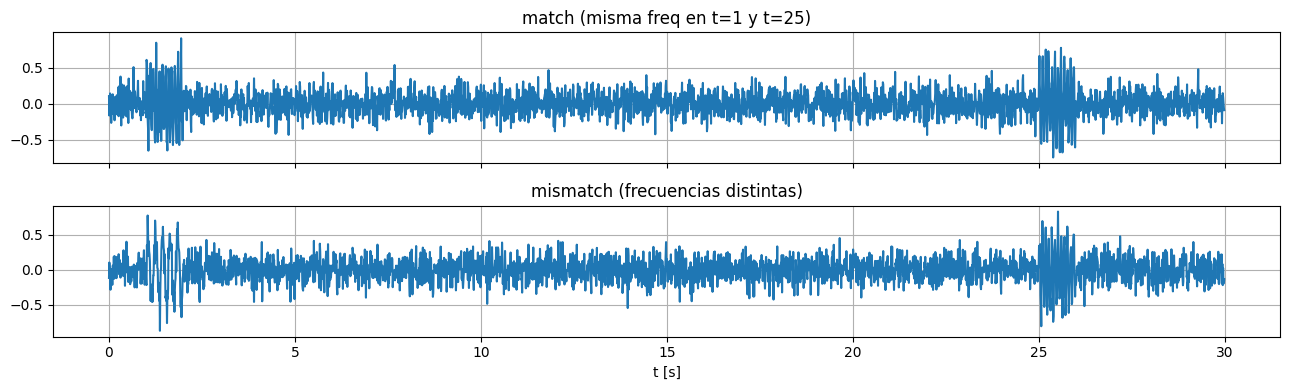

In [ ]:
FS_LC = 100; DUR_LC = 30.0; T_LC = int(DUR_LC * FS_LC)

def make_long_context(label, rng):
    t = np.arange(T_LC) / FS_LC
    sig = 0.15 * rng.standard_normal(T_LC).astype(np.float32)
    f1 = rng.choice([5, 12])
    sig[(t >= 1) & (t < 2)] += 0.5 * np.sin(2*np.pi*f1*t[(t >= 1) & (t < 2)])
    f2 = f1 if label == 0 else (12 if f1 == 5 else 5)
    sig[(t >= 25) & (t < 26)] += 0.5 * np.sin(2*np.pi*f2*t[(t >= 25) & (t < 26)])
    return sig.astype(np.float32)

rng = np.random.default_rng(11); n_per = 400
X_lc = np.stack([make_long_context(c, rng) for c in [0]*n_per + [1]*n_per])
y_lc = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_lc)); X_lc, y_lc = X_lc[idx], y_lc[idx]
split = int(0.8*len(X_lc))
X_tr_lc, X_va_lc = X_lc[:split], X_lc[split:]
y_tr_lc, y_va_lc = y_lc[:split], y_lc[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
axes[0].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 0][0]); axes[0].set_title('match (misma freq en t=1 y t=25)')
axes[1].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 1][0]); axes[1].set_title('mismatch (frecuencias distintas)')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Demo · una CNN no puede resolver esta tarea

Definimos una CNN razonable (3 conv layers con stride=2) y la entrenamos. Su campo receptivo no llega a abarcar los 30 s — queda en *chance level*.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr)),
                        batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = crit(model(xb.to(device).unsqueeze(1)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_va).float().to(device).unsqueeze(1)).argmax(1).cpu().numpy()
    return (pred == y_va).mean()

torch.manual_seed(0)
acc_cnn = train_clf(SmallCNN().to(device), X_tr_lc, y_tr_lc, X_va_lc, y_va_lc)
print(f'SmallCNN val_acc = {acc_cnn:.3f}  (chance = 0.50, CNN limitada por campo receptivo)')

SmallCNN val_acc = 0.525  (chance = 0.50, CNN limitada por campo receptivo)


### Ejercicio 3.1 — implementar y entrenar un mini-Transformer 1D (slide 33)

Implementá un Transformer simple que pueda resolver la tarea. La ventaja sobre la CNN es que **self-attention conecta cualquier par de instantes en una sola capa** — sin importar la distancia.

**Arquitectura:**

```
1. Patch embedding
   Conv1D(in=1, out=64, kernel_size=50, stride=50)   # cada patch = 0.5 s
   transpose para quedar [B, N_patches=60, dim=64]

2. Positional embedding (parámetro aprendido)
   nn.Parameter de shape [1, N_patches=60, dim=64], inicializado random pequeño
   Se suma a la salida del patch embedding

3. Bloque de atención (con conexión residual)
   LayerNorm  →  MultiheadAttention(dim=64, num_heads=4, batch_first=True)
   suma residual con la entrada del bloque

4. Bloque feed-forward (con conexión residual)
   LayerNorm  →  Linear(64 → 128)  →  GELU  →  Linear(128 → 64)
   suma residual

5. Clasificador
   promedio sobre patches (mean dim=1)  →  Linear(64 → 2)
```

**Entrenamiento:** 10 epochs, Adam (lr=3e-4), `CrossEntropyLoss`.

Después de entrenar, comparé el `val_acc` con `acc_cnn`. El Transformer debería resolver la tarea (~1.0), mientras que la CNN se queda en chance.

MiniTransformer1D(
  (patch_embed): Conv1d(1, 64, kernel_size=(50,), stride=(50,))
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (ff): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Parámetros totales: 40,706
Epoch  1/10 — loss: 0.6991  val_acc: 0.5250
Epoch  2/10 — loss: 0.6924  val_acc: 0.4750
Epoch  3/10 — loss: 0.6929  val_acc: 0.5250
Epoch  4/10 — loss: 0.6931  val_acc: 0.4750
Epoch  5/10 — loss: 0.6939  val_acc: 0.4750
Epoch  6/10 — loss: 0.6921  val_acc: 0.4938
Epoch  7/10 — loss: 0.6793  val_acc: 0.4688
Epoch  8/10 — loss: 0.6712  val_acc: 0.4875
Epoch  9/10 — loss: 0.6297  val_acc

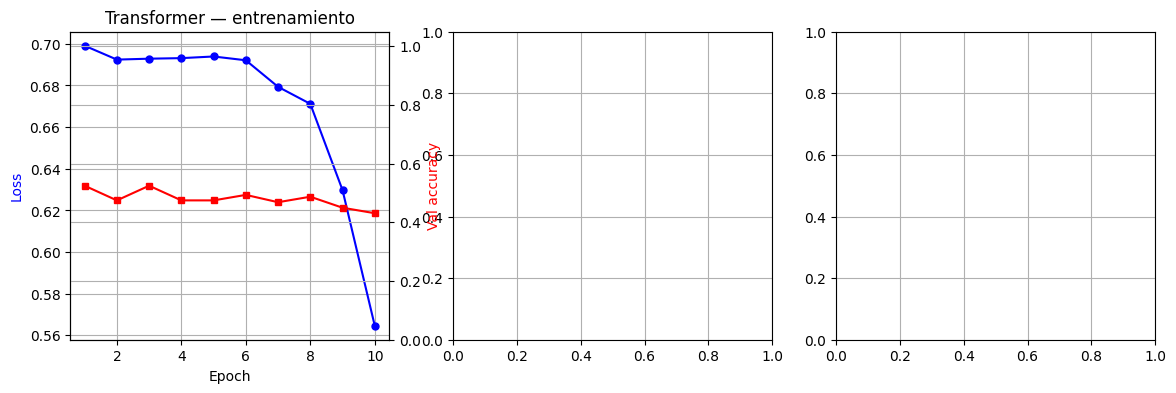

In [ ]:
# Ejercicio 3.1 — mini-Transformer 1D para contexto largo

# ── Arquitectura ──────────────────────────────────────────────────────────────
class MiniTransformer1D(nn.Module):
    """
    Mini-Transformer 1D para clasificación de señales con dependencias largas.
    Cada patch = 50 muestras = 0.5 s a fs=100 Hz → 60 patches por ventana de 30 s.
    Self-attention conecta todos los patches entre sí en una sola capa.
    """
    def __init__(self, n_classes=2, seq_len=3000, patch_size=50,
                 dim=64, n_heads=4, ff_dim=128):
        super().__init__()
        n_patches = seq_len // patch_size   # 3000 // 50 = 60

        # ── 1. Patch embedding ────────────────────────────────────────────────
        # Conv1d recorre la señal en ventanas de 50 muestras sin solapamiento
        # Entrada: (B, 1, T=3000) → Salida conv: (B, dim=64, N=60)
        self.patch_embed = nn.Conv1d(
            in_channels=1,
            out_channels=dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

        # ── 2. Positional embedding (aprendido) ───────────────────────────────
        # Shape (1, 60, 64) — se suma a cada muestra del batch por broadcasting
        self.pos_embed = nn.Parameter(
            torch.randn(1, n_patches, dim) * 0.02
        )

        # ── 3. Bloque de atención ─────────────────────────────────────────────
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=n_heads,
            batch_first=True,   # espera (B, N, dim)
        )

        # ── 4. Bloque feed-forward ────────────────────────────────────────────
        self.norm2 = nn.LayerNorm(dim)
        self.ff    = nn.Sequential(
            nn.Linear(dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, dim),
        )

        # ── 5. Clasificador ───────────────────────────────────────────────────
        self.classifier = nn.Linear(dim, n_classes)

    def forward(self, x):
        # x: (B, 1, T)

        # 1. Patch embedding + transpose → (B, N_patches, dim)
        x = self.patch_embed(x).transpose(1, 2)

        # 2. Sumar positional embedding
        x = x + self.pos_embed

        # 3. Bloque atención con residual
        #    LayerNorm → MHA → suma con entrada
        residual = x
        x_norm   = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = residual + attn_out

        # 4. Bloque feed-forward con residual
        #    LayerNorm → FF → suma con entrada
        x = x + self.ff(self.norm2(x))

        # 5. Promedio sobre patches → (B, dim) → logits (B, 2)
        x = x.mean(dim=1)
        return self.classifier(x)


model_tr = MiniTransformer1D().to(device)

total_params_tr = sum(p.numel() for p in model_tr.parameters())
print(model_tr)
print(f'\nParámetros totales: {total_params_tr:,}')

# ── Entrenamiento: 10 epochs, Adam lr=3e-4, CrossEntropyLoss ─────────────────
dl_tr_lc = DataLoader(
    TensorDataset(torch.from_numpy(X_tr_lc).float(),
                  torch.from_numpy(y_tr_lc)),
    batch_size=32, shuffle=True
)

optimizer_tr = torch.optim.Adam(model_tr.parameters(), lr=3e-4)
criterion     = nn.CrossEntropyLoss()

history_tr = {'train_loss': [], 'val_acc': []}

for epoch in range(10):
    # --- train ---
    model_tr.train()
    running_loss = 0.0
    for xb, yb in dl_tr_lc:
        xb = xb.unsqueeze(1).to(device)   # (B, 1, T)
        yb = yb.to(device)
        optimizer_tr.zero_grad()
        loss = criterion(model_tr(xb), yb)
        loss.backward()
        optimizer_tr.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(dl_tr_lc)

    # --- val ---
    model_tr.eval()
    with torch.no_grad():
        xv = torch.from_numpy(X_va_lc).float().unsqueeze(1).to(device)
        preds = model_tr(xv).argmax(1).cpu().numpy()
    val_acc = (preds == y_va_lc).mean()

    history_tr['train_loss'].append(avg_loss)
    history_tr['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:>2}/10 — loss: {avg_loss:.4f}  val_acc: {val_acc:.4f}')

# ── Comparación CNN vs Transformer ───────────────────────────────────────────
print(f'\n{"Modelo":<22} {"val_acc":>8}  {"¿resuelve?":>12}')
print('-' * 46)
print(f'{"SmallCNN":<22} {acc_cnn:>8.3f}  {"✗ chance level":>12}')
print(f'{"MiniTransformer1D":<22} {val_acc:>8.3f}  {"✓ resuelto" if val_acc > 0.9 else "parcial":>12}')

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Curvas de entrenamiento del Transformer
ax = axes[0]
ax2 = ax.twinx()
ax.plot(range(1, 11), history_tr['train_loss'], 'b-o', ms=5, label='Train loss')
ax2.plot(range(1, 11), history_tr['val_acc'],   'r-s', ms=5, label='Val acc')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='b')
ax2.set_ylabel('Val accuracy', color='r'); ax2.set_ylim(0, 1.05)
ax.set_title('Transformer — entrenamiento')
lines1, labs1 = ax.get_legend_handles_labels()


### Preguntas conceptuales — mini-Transformer (Ej 3.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. El **patch embedding** es una `Conv1D(kernel=50, stride=50)`. ¿Para qué partir la señal en patches? ¿Qué pasaría si pusiéramos todo el tensor directamente en la atención?
2. ¿Cuántos segundos cubre cada patch (a `fs=100 Hz`) y cuántos patches totales hay en una ventana de 30 s?
3. ¿Para qué hace falta el **positional embedding**? ¿Qué pasaría sin él en una tarea como esta (match/mismatch)?
4. En `MultiheadAttention(dim=64, num_heads=4)`: ¿qué representa cada **cabeza** y por qué se usan varias en paralelo?
5. ¿Por qué hay **conexiones residuales** (`e = e + attn_out`)? ¿Qué problema previenen?
6. ¿Para qué sirve el **bloque feed-forward** después de la atención si ya hicimos atención? ¿Por qué la dimensión interna es `2 × EMBED`?
7. ¿Por qué `LayerNorm` y no `BatchNorm` (como sí usamos en EEGNet)?
8. ¿Por qué hacemos `e.mean(dim=1)` al final antes del clasificador?

1. Patches en vez de muestra a muestra
Sin patches, una ventana de 30 s a 100 Hz tiene 3000 tokens y la atención cuesta O(3000²) = 9 millones de operaciones por capa, lo que es inmanejable para un modelo pequeño entrenado desde cero. La Conv1d con stride=50 agrupa 50 muestras contiguas en un único embedding de 64 dimensiones, reduciendo la secuencia a 60 tokens y el costo de atención a O(60²) = 3600 operaciones, sin perder la información de frecuencia relevante (5 y 12 Hz son perfectamente representables en un patch de 0.5 s).
2. Duración y cantidad de patches
50 muestras / 100 Hz = 0.5 segundos por patch. 3000 muestras / 50 = 60 patches por ventana de 30 s. Cada patch cubre suficiente tiempo para contener varios ciclos de las frecuencias de interés (5 Hz → 2.5 ciclos por patch, 12 Hz → 6 ciclos), lo que permite que el embedding capture la frecuencia dominante del evento.
3. Positional embedding — por qué es indispensable aquí
La self-attention es una operación de conjuntos: si permutás los tokens de orden, el resultado es el mismo (solo se permutan las filas de la matriz de atención). Sin positional embedding el modelo no puede distinguir si el spike ocurrió en el segundo 1 o en el segundo 25, y la tarea match/mismatch requiere exactamente saber en qué posición temporal está cada evento para comparar los dos. El embedding aprendido le asigna una identidad posicional única a cada uno de los 60 patches.
4. Múltiples cabezas de atención
Cada cabeza proyecta Q, K, V a un subespacio de dimensión 64/4 = 16 y aprende un patrón de similitud diferente; una cabeza podría especializarse en conectar patches con la misma frecuencia, otra en capturar la estructura local, otra en ignorar el ruido. Usar varias cabezas en paralelo y concatenar sus salidas le da al modelo la capacidad de razonar sobre múltiples tipos de relación simultáneamente, igual que en NLP donde distintas cabezas capturan sintaxis, correferencia y semántica a la vez.
5. Conexiones residuales — para qué sirven
Sin residual, si la atención aprende algo poco útil en las primeras épocas, el gradiente que llega al patch embedding es casi cero y el entrenamiento colapsa. La suma x = x + attn_out garantiza que la señal original siempre fluye hacia adelante sin degradarse, y que el gradiente tiene un camino directo hacia atrás (highway gradient); la atención solo necesita aprender la corrección sobre la representación existente, no reconstruirla desde cero.
6. Bloque feed-forward después de atención
La atención mezcla información entre posiciones pero aplica la misma transformación lineal a cada token: no tiene no-linealidad posición a posición. El feed-forward (con GELU) actúa como una MLP independiente para cada patch, permitiendo transformaciones no lineales complejas dentro de cada posición después de que la atención ya distribuyó el contexto global. La dimensión interna 2×64 = 128 es una heurística del Transformer original (en BERT es 4×, acá se reduce por el tamaño del modelo) que da capacidad suficiente sin overfitting.
7. LayerNorm vs BatchNorm
BatchNorm normaliza sobre el batch en cada posición temporal, lo que requiere batches grandes para estimar bien la media y varianza, y produce estadísticas distintas entre entrenamiento e inferencia (usa running stats). LayerNorm normaliza sobre las dimensiones del embedding para cada muestra independientemente, lo que funciona igual con batch size 1 y es estable durante inferencia sin necesitar running stats; además, en secuencias de longitud variable o señales biológicas con alta variabilidad inter-sujeto, normalizar por muestra es más robusto que normalizar por batch.
8. mean(dim=1) — colapsar la dimensión de patches
El clasificador necesita un vector de tamaño fijo, pero después de la atención tenemos 60 vectores de 64 dimensiones (uno por patch). El promedio sobre los 60 patches produce un único vector de 64 dimensiones que agrega la información de toda la secuencia de forma simétrica; es análogo al GlobalAvgPool de las CNNs y es preferible a tomar solo el primer token (como hace BERT con [CLS]) porque en este modelo no entrenamos un token especial de clasificación.*Tu respuesta acá.*

## Cierre — takeaways de la clase

1. **Una señal 1D = lista de números + `fs`.** ECG, EEG y PPG son instancias del mismo concepto.
2. **El filtro deslizante es el throughline.** Pan-Tompkins → Conv1D → self-attention — lo que cambia es **cuántos parámetros**    y **cuánto contexto** ve cada operación.
3. **AI extiende al clásico, no lo reemplaza.** Pan-Tompkins de 1985 sigue siendo baseline en producción.
4. **Dimensionalidad escala el problema.** ECG (1D) → PPG (1D + movimiento) → EEG (2D = canales × tiempo). El framework es el mismo;    la arquitectura se adapta.
5. **Las CNNs tienen campo receptivo finito.** Cuando la tarea requiere contexto largo, hay que ir a Transformers.